In [9]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from mpl_toolkits.mplot3d import Axes3D
from abc import ABC, abstractmethod
import math
import time
import re
from scipy.optimize import minimize
from itertools import product
import seaborn as sns
from matplotlib import animation
try:
  import numba as nb
  from numba import cuda
except:
  %pip install numba-cuda
  import numba as nb
  from numba import cuda
try:
  import cupy as cp
except:
  %pip install cupy-cuda12x

FORCE_MAT_TILE_DIM = 32
SEGMENT = 32
FORCE_MAT_REDUC_BLOCK_DIM = 512 # must be power of 2
FORCE_MAT_EXPLICIT_BLOCK_DIM = 512
SPACE_N_DIM = 3

IDENTITY = 0
HARMONIC = 1
REPULSIVE = 2
ATTRACTIVE = 3

BOX_SIZE_IDX = 0
K_IDX = 1
R0_IDX = 2
EPSILON_ATTRACTIVE_IDX = 3
EPSILON_REPULSIVE_IDX = 4
SIGMA_IDX = 5

NB_FLOAT32 = 32
NB_FLOAT64 = 64

DIV_BY_ZERO_GUARD = 1e-12

# Initialize Positions and Velocities

In [2]:
@nb.njit
def assign_position(positions, new_positions, idx):
    positions[0, idx] = new_positions[0]
    positions[1, idx] = new_positions[1]
    positions[2, idx] = new_positions[2]

@nb.njit
def initialize_chain_numba(
    n_particles: int,
    box_size: float,
    r0: float,
    rng: np.random._generator.Generator,
    dtype=np.float32
) -> np.ndarray:
    """
    Randomly initialize atom positions by growing the chain
    """
    positions = np.zeros((3, n_particles), dtype=dtype)

    current_position = np.array([box_size / 2, box_size / 2, box_size / 2], dtype=dtype)
    assign_position(positions, current_position, 0)

    for i in range(1, n_particles):
        direction = rng.normal(size = 3).astype(dtype)
        norm = np.sqrt(direction[0]**2 + direction[1]**2 + direction[2]**2)
        direction /= norm

        next_position = current_position + r0 * direction
        next_position = (next_position % box_size).astype(dtype) # pbc
        assign_position(positions, next_position, i)
        current_position = next_position

    return positions

def initialize_velocities_cupy(
    n_particles: int,
    target_temperature: float, 
    mass: float,
    rng: cp.random._generator_api.Generator,
    kB=1.0,
    dtype=cp.float32
) -> cp.ndarray:
    """
    Initialize particle velocities by drawing from the Maxwell-Botzmann distribution at target temperature
    """
    sigma = cp.sqrt(kB * target_temperature / mass).astype(dtype)

    velocities = rng.standard_normal(
        size=(3, n_particles), 
        dtype=dtype
    )
    velocities = velocities * sigma

    # Remove center-of-mass velocity
    velocities -= cp.mean(velocities, axis=-1).reshape(3, 1)

    return velocities

In [32]:
# qc
rng_np = np.random.default_rng(42)
pos = initialize_chain_numba(10, 20.0, 1.0, rng_np)
rng_cp = cp.random.default_rng(42)
v = initialize_velocities_cupy(1000, target_temperature=1.0, mass=1.0, rng = rng_cp)
v

array([[-0.95401406, -0.22627392, -0.7407161 , ...,  0.61938095,
        -0.38514563,  1.0126818 ],
       [ 0.71394455,  1.9269174 , -0.1572528 , ...,  0.41389567,
         3.342068  ,  0.21708886],
       [-0.1798589 ,  0.09168955, -0.7073451 , ..., -0.524985  ,
        -0.01233297,  0.936227  ]], dtype=float32)

# Compute Forces

## Harmonic Forces

In [19]:
@nb.njit
def minimum_image(displacement, box_size):
    """
    Apply minimum image convention to a 3D displacement vector.
    """
    out = np.empty(3, dtype=displacement.dtype)
    for d in range(3):
        out[d] = displacement[d] - box_size * np.round(displacement[d] / box_size)
    return out

@nb.njit
def compute_harmonic_forces(positions, k, r0, box_size):
    """
    Compute harmonic bond forces for a linear chain.

    Parameters
    ----------
    positions : array, shape (n_particles, 3)
        Particle positions.
    k : float
        Harmonic spring constant.
    r0 : float
        Equilibrium bond length.
    box_size : float
        Periodic box length.

    Returns
    -------
    forces : array, shape (n_particles, 3)
        Force on each particle.
    """
    n_particles = positions.shape[0]
    forces = np.zeros_like(positions)

    for i in range(n_particles - 1):
        displacement = np.empty(3, dtype=positions.dtype)
        for d in range(3):
            displacement[d] = positions[i + 1, d] - positions[i, d]

        displacement = minimum_image(displacement, box_size)

        distance_sq = 0.0
        for d in range(3):
            distance_sq += displacement[d] * displacement[d]
        distance = np.sqrt(distance_sq)

        if distance > 0.0:
            force_magnitude = -k * (distance - r0)

            for d in range(3):
                force_component = force_magnitude * displacement[d] / distance
                forces[i, d] -= force_component
                forces[i + 1, d] += force_component

    return forces


In [ ]:
@cuda.jit(device=True)
def minimum_image_1d(dx, box_size):
    return dx - box_size * round(dx / box_size)

@cuda.jit
def compute_bond_forces_kernel(positions, bond_forces, k, r0, box_size, n_particles):
    sh_pos = cuda.shared.array(shape=(129, 3), dtype=nb.float32)

    tid = cuda.threadIdx.x
    bid = cuda.blockIdx.x
    bdim = cuda.blockDim.x

    i = bid * bdim + tid      # global bond index
    p = bid * bdim + tid      # global particle index to load

    # Load one particle per thread
    if p < n_particles:
        sh_pos[tid, 0] = positions[p, 0]
        sh_pos[tid, 1] = positions[p, 1]
        sh_pos[tid, 2] = positions[p, 2]

    # Last thread loads the extra halo particle
    if tid == bdim - 1:
        p_extra = p + 1
        if p_extra < n_particles:
            sh_pos[tid + 1, 0] = positions[p_extra, 0]
            sh_pos[tid + 1, 1] = positions[p_extra, 1]
            sh_pos[tid + 1, 2] = positions[p_extra, 2]

    cuda.syncthreads()

    if i < n_particles - 1:
        dx = sh_pos[tid + 1, 0] - sh_pos[tid, 0]
        dy = sh_pos[tid + 1, 1] - sh_pos[tid, 1]
        dz = sh_pos[tid + 1, 2] - sh_pos[tid, 2]

        dx = minimum_image_1d(dx, box_size)
        dy = minimum_image_1d(dy, box_size)
        dz = minimum_image_1d(dz, box_size)

        dist = math.sqrt(dx * dx + dy * dy + dz * dz)

        if dist > 0.0:
            force_mag = -k * (dist - r0)
            inv_dist = 1.0 / dist
            bond_forces[i, 0] = force_mag * dx * inv_dist
            bond_forces[i, 1] = force_mag * dy * inv_dist
            bond_forces[i, 2] = force_mag * dz * inv_dist
        else:
            bond_forces[i, 0] = 0.0
            bond_forces[i, 1] = 0.0
            bond_forces[i, 2] = 0.0

@cuda.jit
def assemble_forces_kernel(bond_forces, forces, n_particles):
    p = cuda.grid(1)

    if p < n_particles:
        fx = 0.0
        fy = 0.0
        fz = 0.0

        # left bond contributes positively
        if p > 0:
            fx += bond_forces[p - 1, 0]
            fy += bond_forces[p - 1, 1]
            fz += bond_forces[p - 1, 2]

        # right bond contributes negatively
        if p < n_particles - 1:
            fx -= bond_forces[p, 0]
            fy -= bond_forces[p, 1]
            fz -= bond_forces[p, 2]

        forces[p, 0] = fx
        forces[p, 1] = fy
        forces[p, 2] = fz

inf
nan
inf
inf
inf
nan
inf
inf
inf
nan
nan
inf
inf
935.62286
nan
inf
inf
920.6522
nan
inf
inf
nan
inf
inf
inf
nan
inf
inf
inf
nan


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


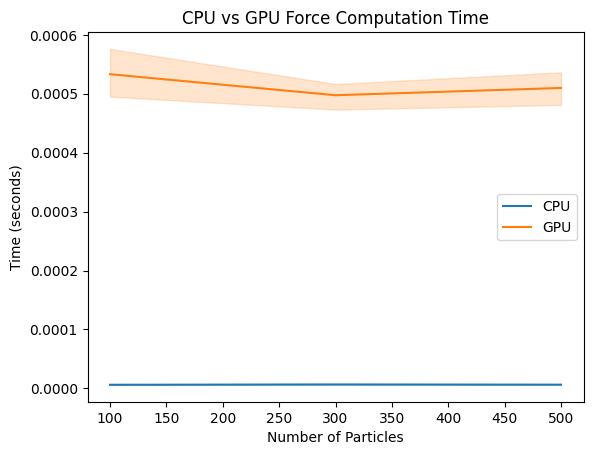

In [26]:
import time
import numpy as np
import pandas as pd
import cupy as cp
import matplotlib.pyplot as plt
import seaborn as sns
from numba import cuda

time_df = pd.DataFrame(columns=["n_particles", "cpu_time", "gpu_time"])

n_warmups = 3
n_trials = 10
sizes = [100, 300, 500]
TPB = 128

for n_particles in sizes:
    for i in range(n_warmups + n_trials):
        rng = np.random.default_rng(i)

        box_size = 20.0
        r0 = 1.0
        k = 100.0

        positions = np.asarray(
            initialize_chain_numba(n_particles, box_size, r0, rng),
            dtype=np.float32
        )

        positions_gpu = cp.asarray(positions, dtype=cp.float32)
        bond_forces_gpu = cp.zeros((n_particles - 1, 3), dtype=cp.float32)
        forces_gpu = cp.zeros((n_particles, 3), dtype=cp.float32)

        # CPU timing
        start = time.perf_counter()
        forces_cpu = compute_harmonic_forces(positions, k, r0, box_size)
        cpu_time = time.perf_counter() - start

        # GPU timing
        blocks_bonds = (n_particles - 1 + TPB - 1) // TPB
        blocks_particles = (n_particles + TPB - 1) // TPB

        start = time.perf_counter()
        compute_bond_forces_kernel[blocks_bonds, TPB](
            positions_gpu, bond_forces_gpu, k, r0, box_size, n_particles
        )
        assemble_forces_kernel[blocks_particles, TPB](
            bond_forces_gpu, forces_gpu, n_particles
        )
        cuda.synchronize()
        gpu_time = time.perf_counter() - start

        if i >= n_warmups:
            time_df.loc[len(time_df)] = [n_particles, cpu_time, gpu_time]
            forces_gpu_host = cp.asnumpy(forces_gpu)
            print(np.max(np.abs(forces_cpu - forces_gpu_host.T)))
            
sns.lineplot(data=time_df, x="n_particles", y="cpu_time", label="CPU")
sns.lineplot(data=time_df, x="n_particles", y="gpu_time", label="GPU")
plt.xlabel("Number of Particles")
plt.ylabel("Time (seconds)")
plt.title("CPU vs GPU Force Computation Time")
plt.legend()
plt.show()

## Lennard-Jones Forces

In [8]:
@nb.njit
def compute_lennard_jones_forces_njit(
    positions,
    n_particles,
    epsilon_repulsive,
    epsilon_attractive,
    sigma,
    box_size,
    cutoff
):
    forces = np.zeros_like(positions)

    cutoff_sq = cutoff * cutoff

    for i in range(n_particles):
        for j in range(i + 1, n_particles):
            sep = j - i

            if sep == 2:
                epsilon = epsilon_repulsive
            elif sep > 2:
                epsilon = epsilon_attractive
            else:
                continue

            displacement = np.empty(3, dtype=positions.dtype)
            for d in range(3):
                displacement[d] = positions[j, d] - positions[i, d]

            displacement = minimum_image(displacement, box_size)

            r2 = 0.0
            for d in range(3):
                r2 += displacement[d] * displacement[d]

            if r2 < cutoff_sq and r2 > 0.0:
                r = np.sqrt(r2)
                sr = sigma / r
                sr2 = sr * sr
                sr6 = sr2 * sr2 * sr2
                sr12 = sr6 * sr6

                force_magnitude = 24.0 * epsilon * (sr12 - 0.5 * sr6) / r

                for d in range(3):
                    force_component = force_magnitude * displacement[d] / r
                    forces[i, d] -= force_component
                    forces[j, d] += force_component

    return forces

# Force Computation

In [3]:
@nb.njit
def harmonic_force(r, k, r0):
  return -k * (r-r0)

well_coeff = 2**(1/6)
@nb.njit
def repulsive_lj_force(r, sigma, epsilon):
  if r < well_coeff*sigma:
    r = max(r, DIV_BY_ZERO_GUARD)
    sixth_pow = (sigma/r) ** 6
    return -24*epsilon/r * (sixth_pow - 2*(sixth_pow**2))
  else:
    return 0

@nb.njit
def attractive_lj_force(r, sigma, epsilon):
  r = max(r, DIV_BY_ZERO_GUARD)
  sixth_pow = (sigma/r) ** 6
  return -24*epsilon/r * (sixth_pow - 2*(sixth_pow**2))

In [4]:
@nb.njit
def calc_force(distance, params, type):
  if type == HARMONIC or type == -HARMONIC:
     return harmonic_force(distance, params[K_IDX], params[R0_IDX])
  if type == REPULSIVE or type == -REPULSIVE:
     return repulsive_lj_force(distance, params[SIGMA_IDX], params[EPSILON_REPULSIVE_IDX])
  if type >= ATTRACTIVE or type <= -ATTRACTIVE:
     return attractive_lj_force(distance, params[SIGMA_IDX], params[EPSILON_ATTRACTIVE_IDX])
  return 0

@nb.njit
def minimum_image_1d(dx, box_size):
    return dx - box_size * math.floor((dx / box_size) + 0.5)

## Compare: Sequential

In [5]:
@nb.njit
def calc_force_sequential(
  forces: np.ndarray, # global forces array (output)
  positions: np.ndarray # global positions array (input)
):
  forces.fill(0)
  params = const_params
  n_particles = positions.shape[1]
  for i in range(n_particles-1):
    for j in range(i+1, n_particles):
      distance = 0
      for k in range(SPACE_N_DIM):
        dx = minimum_image_1d(positions[k, i] - positions[k, j], params[BOX_SIZE_IDX])
        distance += dx**2
      distance = math.sqrt(distance)
      magnitude = calc_force(distance, params, j - i)
      for k in range(SPACE_N_DIM):
        f = magnitude * minimum_image_1d(positions[k, i] - positions[k, j], params[BOX_SIZE_IDX]) / max(distance, DIV_BY_ZERO_GUARD)
        forces[k, i] += f
        forces[k, j] -= f

## Method 0: Segmented Traversal

In [149]:
@cuda.jit
def calc_force_segmented(
  forces: cp.ndarray, # global forces array (output)
  positions: cp.ndarray, # global positions array (input)
):
  dtype = nb.float64
  params = cuda.const.array_like(const_params)

  idx = cuda.grid(1)
  receiver_position = cuda.local.array(shape = SPACE_N_DIM, dtype = dtype)
  if idx < positions.shape[1]:
    for dim in range(SPACE_N_DIM):
      receiver_position[dim] = positions[dim, idx]

  src_positions = cuda.shared.array(shape = (SEGMENT, 3), dtype = dtype)
  force = cuda.local.array(shape = SPACE_N_DIM, dtype = dtype)
  for i in range(SPACE_N_DIM):
    force[i] = 0

  for start in range(0, positions.shape[1], SEGMENT):
    sweep = min(SEGMENT, positions.shape[1] - start)
    # cooperate to load src positions
    if cuda.threadIdx.x < sweep:
      for dim in range(SPACE_N_DIM):
        src_positions[cuda.threadIdx.x, dim] = positions[dim, start + cuda.threadIdx.x]
    cuda.syncthreads()

    # calculate
    if idx < positions.shape[1]:
      for i in range(sweep):
        distance = 0
        for dim in range(SPACE_N_DIM):
          distance += minimum_image_1d(receiver_position[dim] - src_positions[i, dim], params[BOX_SIZE_IDX])**2
        distance = math.sqrt(distance)
        magnitude = calc_force(
          distance,
          params,
          idx - (start + i)
        )
        for dim in range(SPACE_N_DIM):
          force[dim] += magnitude * minimum_image_1d(receiver_position[dim] - src_positions[i, dim], params[BOX_SIZE_IDX]) / max(distance, DIV_BY_ZERO_GUARD)
    cuda.syncthreads()
  if idx < positions.shape[1]:
    for dim in range(SPACE_N_DIM):
      forces[dim, idx] = force[dim] 

## Test and Timing

In [66]:
const_params = np.array([100, 300, 1, 0.5, 1.0, 1.0])

rng_np = np.random.default_rng(42)
n_atoms = 10000
pos = initialize_chain_numba(n_atoms, 100.0, 1.0, rng_np, dtype = np.float64)

In [67]:
positions_d = cp.array(pos)
forces_d = cp.zeros_like(pos)
grid_dim = (n_atoms + SEGMENT - 1) // SEGMENT
calc_force_segmented[grid_dim, SEGMENT](forces_d, positions_d)

In [68]:
forces_d

array([[-2.52854841e+07, -3.77869361e+05,  7.91022286e+03, ...,
        -7.95326970e-01, -1.23773791e+02,  5.86685413e-01],
       [-1.10749700e+07,  3.14572448e+05,  1.17366176e+04, ...,
        -1.58781823e+01,  1.15690894e+01, -6.40460402e-01],
       [ 9.23030897e+06, -6.53955229e+05, -1.81171825e+04, ...,
        -1.05724809e+01, -9.66689840e+01,  2.72326892e-01]])

In [69]:
forces_h = np.zeros_like(pos, dtype=np.float64)
calc_force_sequential(forces_h, pos)
forces_h

array([[-2.52854841e+07, -3.77869361e+05,  7.91022286e+03, ...,
        -7.95326970e-01, -1.23773791e+02,  5.86685413e-01],
       [-1.10749700e+07,  3.14572448e+05,  1.17366176e+04, ...,
        -1.58781823e+01,  1.15690894e+01, -6.40460402e-01],
       [ 9.23030897e+06, -6.53955229e+05, -1.81171825e+04, ...,
        -1.05724809e+01, -9.66689840e+01,  2.72326892e-01]])

In [70]:
np.allclose(forces_h, forces_d.get())

True

In [21]:
%%timeit
calc_force_segmented[grid_dim, SEGMENT](forces_d, positions_d)

90 ms ± 49.2 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [25]:
const_params = np.array([100, 300, 1, 0.5, 1.0, 1.0])
rng_np = np.random.default_rng(42)
chain_lens = np.round(np.logspace(1, 5, 10)).astype(np.int32)
n_itr = 5
time_df = []
for chain_len in tqdm(chain_lens):
  pos = initialize_chain_numba(chain_len, chain_len*2.5, 1.0, rng_np, dtype = np.float64)
  positions_d = cp.array(pos, dtype = cp.float64)
  forces_d = cp.zeros_like(pos, dtype = cp.float64)
  grid_dim = (n_atoms + SEGMENT - 1) // SEGMENT

  # gpu
  st_times = []
  for i in range(n_itr):
    start_event = cuda.event()
    end_event = cuda.event()
    start_event.record()
    calc_force_segmented[grid_dim, SEGMENT](forces_d, positions_d)
    end_event.record()
    end_event.synchronize()
    execution_time_ms = cuda.event_elapsed_time(start_event, end_event)
    st_times.append(execution_time_ms * 1e6)
  st_df = pd.DataFrame({"time": st_times, "n_atom": chain_len, "itr": range(n_itr), "type": "segmented_traversal"})
  time_df.append(st_df)

time_df = pd.concat(time_df)

  0%|          | 0/10 [00:00<?, ?it/s]

In [26]:
time_df.to_csv("segmented_traversal_timing.csv", index = False)

## Method 1: Force Matrix

Map block (blockIdx = b) to upper triangular tiles (row, col)
- r = $\lceil N - 0.5 - \frac{\sqrt{(2N+1)^2-8(b+1)}}{2} \rceil $
- c = $b+r-\frac{(2N-r+1)r}{2}$

In [150]:
@cuda.jit
def calc_force_matrix(
  forces: cp.ndarray, # global forces array (output)
  positions: cp.ndarray, # global positions array (input)
  tile_n: int
):
  dtype = nb.float64
  params = cuda.const.array_like(const_params)

  # heavy index calculation once per block
  
  block_idx = cuda.shared.array(shape = 2, dtype = nb.int32) # row, col
  if cuda.threadIdx.x == 0:
    row = math.ceil(tile_n - 0.5 - math.sqrt((2*tile_n+1)*(2*tile_n+1) - 8*(cuda.blockIdx.x+1))/2)
    col = cuda.blockIdx.x + row - (2*tile_n-row+1)*row//2
    block_idx[0] = row * FORCE_MAT_TILE_DIM
    block_idx[1] = col * FORCE_MAT_TILE_DIM
  cuda.syncthreads()

  # load source positions to shared memory
  sweep = min(FORCE_MAT_TILE_DIM, forces.shape[1]-block_idx[0])
  src_positions = cuda.shared.array(shape = (FORCE_MAT_TILE_DIM, 3), dtype = dtype)
  if cuda.threadIdx.x < sweep:
    for dim in range(SPACE_N_DIM):
      src_positions[cuda.threadIdx.x, dim] = positions[dim, block_idx[0]+cuda.threadIdx.x]
  cuda.syncthreads()

  receiver_idx = block_idx[1] + cuda.threadIdx.x

  # ---------------------- diagonal --------------------------------
  if block_idx[0] == block_idx[1]:
    if receiver_idx < forces.shape[1]: # this guarantees threadIdx < sweep since the force matrix is a square matrix
      # load receiver positions
      receiver_position = cuda.local.array(shape = 3, dtype = dtype)
      for dim in range(SPACE_N_DIM):
        receiver_position[dim] = src_positions[cuda.threadIdx.x, dim]
      
      col_sum = cuda.local.array(shape = SPACE_N_DIM, dtype = dtype)
      for i in range(SPACE_N_DIM):
        col_sum[i] = 0
      for i in range(1, sweep): # start from 1 to skip calculating forces by itself, avoid division by 0 distance
        # juxtapose src indices
        # when not diagonal, minimize shared memory contention
        src_idx = (i + cuda.threadIdx.x) % sweep
        distance = 0
        for dim in range(SPACE_N_DIM):
          distance += minimum_image_1d(receiver_position[dim] - src_positions[src_idx, dim], params[BOX_SIZE_IDX])**2
        distance = math.sqrt(distance)
        magnitude = calc_force(
          distance,
          params,
          receiver_idx - (block_idx[0] + src_idx)
        )
        for dim in range(SPACE_N_DIM):
          col_sum[dim] += magnitude * minimum_image_1d(receiver_position[dim] - src_positions[src_idx, dim], params[BOX_SIZE_IDX]) / max(distance, DIV_BY_ZERO_GUARD)
      for dim in range(SPACE_N_DIM):
        cuda.atomic.add(forces, (dim, receiver_idx), col_sum[dim])
  
  # ---------------------- non-diagonal --------------------------------
  else:
    row_sums = cuda.shared.array(shape = (FORCE_MAT_TILE_DIM, 3), dtype = dtype) # sweep must be equal to tile dim when it's not a diagonal block
    for i in range(SPACE_N_DIM):
      row_sums[cuda.threadIdx.x, i] = 0
    cuda.syncthreads()

    if receiver_idx < forces.shape[1]:
      col_sum = cuda.local.array(shape = SPACE_N_DIM, dtype = dtype)
      for i in range(SPACE_N_DIM):
        col_sum[i] = 0
      receiver_position = cuda.local.array(shape = SPACE_N_DIM, dtype = dtype)
      for dim in range(SPACE_N_DIM):
        receiver_position[dim] = positions[dim, receiver_idx]
      
      for i in range(sweep):
        src_idx = (i + cuda.threadIdx.x) % sweep
        distance = 0
        for dim in range(SPACE_N_DIM):
          distance += minimum_image_1d(receiver_position[dim] - src_positions[src_idx, dim], params[BOX_SIZE_IDX])**2
        distance = math.sqrt(distance)
        magnitude = calc_force(
          distance,
          params,
          receiver_idx - (block_idx[0] + src_idx)
        )
        for dim in range(SPACE_N_DIM):
          f = magnitude * minimum_image_1d(receiver_position[dim] - src_positions[src_idx, dim], params[BOX_SIZE_IDX]) / max(distance, DIV_BY_ZERO_GUARD)
          col_sum[dim] += f
          cuda.atomic.add(row_sums, (src_idx, dim), -f) # no race condition when FORCE_MAT_TILE_DIM <= WARP_SIZE
      for dim in range(SPACE_N_DIM):
        cuda.atomic.add(forces, (dim, receiver_idx), col_sum[dim])

    cuda.syncthreads()

    if cuda.threadIdx.x < sweep:
      for dim in range(SPACE_N_DIM):
        cuda.atomic.add(forces, (dim, cuda.threadIdx.x+block_idx[0]), row_sums[cuda.threadIdx.x, dim])

## Test and Timing

In [10]:
const_params = np.array([100, 300, 1, 0.5, 1.0, 1.0])

rng_np = np.random.default_rng(42)
pos = initialize_chain_numba(10000, 100.0, 1.0, rng_np, dtype = np.float64)

In [11]:
positions_d = cp.array(pos)
forces_d = cp.zeros_like(pos)
tile_n = math.ceil(positions_d.shape[1] / FORCE_MAT_TILE_DIM)
grid_dim = tile_n * (1 + tile_n) // 2
calc_force_matrix[grid_dim, FORCE_MAT_TILE_DIM](forces_d, positions_d, tile_n)

In [12]:
forces_d

array([[-2.52854841e+07, -3.77869361e+05,  7.91022286e+03, ...,
        -7.95326970e-01, -1.23773791e+02,  5.86685413e-01],
       [-1.10749700e+07,  3.14572448e+05,  1.17366176e+04, ...,
        -1.58781823e+01,  1.15690894e+01, -6.40460402e-01],
       [ 9.23030897e+06, -6.53955229e+05, -1.81171825e+04, ...,
        -1.05724809e+01, -9.66689840e+01,  2.72326892e-01]])

In [13]:
forces_h = np.zeros_like(pos, dtype=np.float64)
calc_force_sequential(forces_h, pos)

In [14]:
forces_h

array([[-2.52854841e+07, -3.77869361e+05,  7.91022286e+03, ...,
        -7.95326970e-01, -1.23773791e+02,  5.86685413e-01],
       [-1.10749700e+07,  3.14572448e+05,  1.17366176e+04, ...,
        -1.58781823e+01,  1.15690894e+01, -6.40460402e-01],
       [ 9.23030897e+06, -6.53955229e+05, -1.81171825e+04, ...,
        -1.05724809e+01, -9.66689840e+01,  2.72326892e-01]])

In [20]:
np.allclose(forces_h, forces_d.get())

True

In [14]:
%%timeit
calc_force_matrix[grid_dim, FORCE_MAT_TILE_DIM](forces_d, positions_d, tile_n)

45.7 ms ± 28.7 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [15]:
%%timeit
calc_force_sequential(forces_h, pos)

1.81 s ± 222 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [41]:
const_params = np.array([100, 300, 1, 0.5, 1.0, 1.0])
rng_np = np.random.default_rng(42)
chain_lens = np.round(np.logspace(1, 5, 10)).astype(np.int32)
n_itr = 5
time_df = []
for chain_len in tqdm(chain_lens):
  pos = initialize_chain_numba(chain_len, chain_len*2.5, 1.0, rng_np, dtype = np.float64)
  positions_d = cp.array(pos, dtype = cp.float64)
  forces_d = cp.zeros_like(pos, dtype = cp.float64)
  tile_n = math.ceil(positions_d.shape[1] / FORCE_MAT_TILE_DIM)
  grid_dim = tile_n * (1 + tile_n) // 2
  forces_h = np.zeros_like(pos, dtype=np.float64)

  # gpu
  fm_times = []
  for i in range(n_itr):
    start_event = cuda.event()
    end_event = cuda.event()
    start_event.record()
    calc_force_matrix[grid_dim, FORCE_MAT_TILE_DIM](forces_d, positions_d, tile_n)
    end_event.record()
    end_event.synchronize()
    execution_time_ms = cuda.event_elapsed_time(start_event, end_event)
    fm_times.append(execution_time_ms * 1e6)
  fm_df = pd.DataFrame({"time": fm_times, "n_atom": chain_len, "itr": range(n_itr), "type": "force_matrix"})
  
  # cpu
  cpu_times = []
  for i in range(n_itr):
    cpu_start = time.perf_counter_ns()
    calc_force_sequential(forces_h, pos)
    cpu_end = time.perf_counter_ns()
    cpu_times.append(cpu_end - cpu_start)
  cpu_df = pd.DataFrame({"time": cpu_times, "n_atom": chain_len, "itr": range(n_itr), "type": "cpu"})
  time_df.append(pd.concat([fm_df, cpu_df]))

time_df = pd.concat(time_df)

  0%|          | 0/10 [00:00<?, ?it/s]

In [47]:
time_df.to_csv("force_matrix_timing.csv", index = False)

In [27]:
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(multiple=True)
display(uploader)

FileUpload(value={}, description='Upload', multiple=True)

In [28]:
for filename, file_info in uploader.value.items():
    with open(filename, "wb") as f:
        f.write(file_info['content'])

In [ ]:
time_df1 = pd.read_csv("force_matrix_timing.csv")
time_df2 = pd.read_csv("segmented_traversal_timing.csv")
time_df = pd.concat([time_df1, time_df2])

In [ ]:
time_df.to_csv("timing_df.csv", index = False)

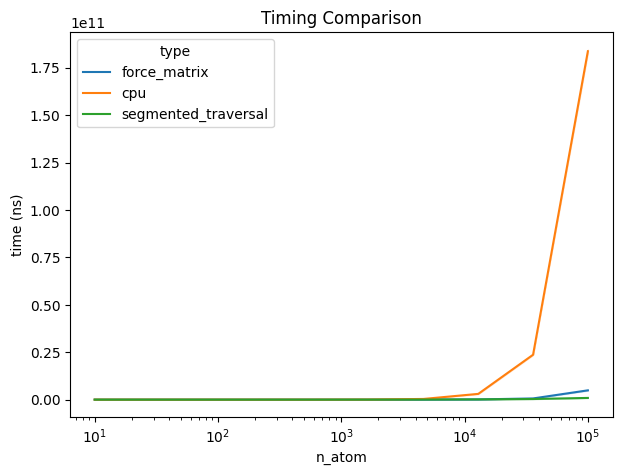

In [39]:
fig, ax = plt.subplots(figsize = (7, 5))
sns.lineplot(time_df, x = "n_atom", y = "time", hue = "type", ax = ax)
ax.set_xscale('log')
ax.set_ylabel("time (ns)")
ax.set_title("Timing Comparison")
fig.savefig("timing_comparison.png", dpi=300)

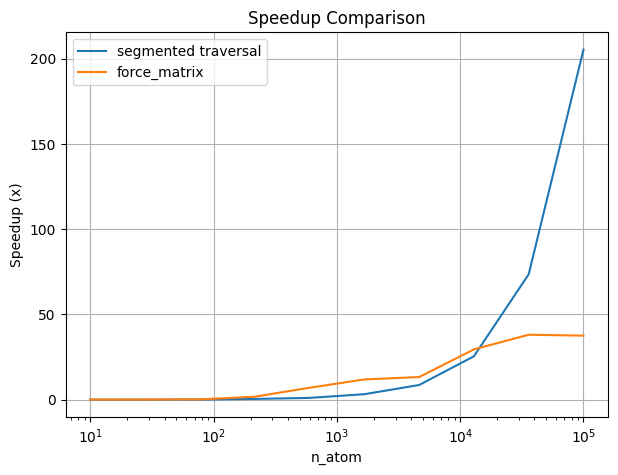

In [41]:
comp_df = time_df.groupby(by = ["n_atom", "type"])['time'].agg("mean").reset_index()
comp_df = comp_df.pivot(index = "n_atom", columns = "type", values = "time").reset_index()
comp_df['speedup_force_matrix'] = comp_df['cpu'] / comp_df['force_matrix']
comp_df['speedup_segmented_traversal'] = comp_df['cpu'] / comp_df['segmented_traversal']
fig, ax = plt.subplots(figsize = (7, 5))
sns.lineplot(comp_df, x='n_atom', y='speedup_segmented_traversal', ax=ax, label = "segmented traversal")
sns.lineplot(comp_df, x='n_atom', y='speedup_force_matrix', ax=ax, label = "force_matrix")
ax.set_xscale('log')
ax.set_ylabel("Speedup (x)")
ax.grid()
ax.set_title("Speedup Comparison")
fig.savefig("speedup_comparison.png", dpi=300)

# Method 2: Explicit Force Matrix

Map thread (global index = b) to upper triangular tiles (row, col). $n$ is number of atoms here
- r = $\lceil n - 0.5 - \frac{\sqrt{(2n+1)^2-8(b+1)}}{2} \rceil $
- c = $b+r-\frac{(2n-r+1)r}{2}$ 

Map (row, col) to idx:
- idx = $\frac{(2n-r+1)r}{2} +c-r$

In [14]:
@cuda.jit
def calc_force_matrix_explicit(
  forces_mat: cp.ndarray, # global forces matrix array (1d) (output)
  positions: cp.ndarray # global positions array (input)
):
  dtype = nb.float64
  params = cuda.const.array_like(const_params)
  idx = cuda.grid(1)
  n = positions.shape[1] - 1 # -1 since we don't need the diagonal entries
  if idx >= n*(n+1)//2:
    return

  row = int(math.ceil(n - 0.5 - math.sqrt((2*n+1)*(2*n+1) - 8*(idx+1))/2))
  col = idx + row - (2*n-row+1)*row//2 + 1 # +1 since we don't need the diagonal entries
  
  src_positions = cuda.local.array(SPACE_N_DIM, dtype = dtype)
  receiver_positions = cuda.local.array(SPACE_N_DIM, dtype = dtype)
  for dim in range(SPACE_N_DIM):
    src_positions[dim] = positions[dim, row]
    receiver_positions[dim] = positions[dim, col]
  distance = 0
  for dim in range(SPACE_N_DIM):
    distance += minimum_image_1d(receiver_positions[dim] - src_positions[dim], params[BOX_SIZE_IDX])**2
  distance = math.sqrt(distance)
  magnitude = calc_force(
    distance,
    params,
    col - row
  )
  for dim in range(SPACE_N_DIM):
    forces_mat[dim, idx] = magnitude * minimum_image_1d(receiver_positions[dim] - src_positions[dim], params[BOX_SIZE_IDX]) / max(distance, DIV_BY_ZERO_GUARD)

In [52]:
@cuda.jit
def force_mat_sum(
  forces_mat: cp.ndarray, # upper diagonal matrix stored as 1d array
  forces: cp.ndarray # output array
):
  dtype = nb.float64
  coarsen_factor = (forces.shape[1] + FORCE_MAT_REDUC_BLOCK_DIM - 1) // FORCE_MAT_REDUC_BLOCK_DIM
  n = forces.shape[1] - 1
  results = cuda.shared.array(shape = (FORCE_MAT_REDUC_BLOCK_DIM, SPACE_N_DIM), dtype = dtype)

  result = cuda.local.array(shape = SPACE_N_DIM, dtype = dtype)
  for dim in range(SPACE_N_DIM):
    result[dim] = 0
  for idx in range(cuda.threadIdx.x*coarsen_factor, min(forces.shape[1], (cuda.threadIdx.x+1)*coarsen_factor)):
    col = cuda.blockIdx.x
    row = idx
    if row == col:
      continue
    coeff = 1
    if row > col:
      row, col = col, row
      coeff = -1
    col -= 1
    mat_idx = (2*n-row+1)*row//2 + col - row
    for dim in range(SPACE_N_DIM):
      result[dim] += coeff*forces_mat[dim, mat_idx]
  for dim in range(SPACE_N_DIM):
    results[cuda.threadIdx.x, dim] = result[dim]
  cuda.syncthreads()

  block = FORCE_MAT_REDUC_BLOCK_DIM // 2
  while block > 0:
    if cuda.threadIdx.x < block:
      for dim in range(SPACE_N_DIM):
        results[cuda.threadIdx.x, dim] += results[cuda.threadIdx.x + block, dim]
    block //= 2
    cuda.syncthreads()
  
  if cuda.threadIdx.x == 0:
    for dim in range(SPACE_N_DIM):
      forces[dim, cuda.blockIdx.x] = results[0, dim]

In [40]:
const_params = np.array([100, 300, 1, 0.5, 1.0, 1.0])
n_atoms = 1000
rng_np = np.random.default_rng(42)
pos = initialize_chain_numba(n_atoms, 100.0, 1.0, rng_np, dtype = np.float64)

In [53]:
positions_d = cp.array(pos)
forces_d = cp.zeros_like(pos)
n_threads = (n_atoms-1) * (1 + (n_atoms-1)) // 2
grid_dim = (n_threads + FORCE_MAT_EXPLICIT_BLOCK_DIM - 1) // FORCE_MAT_EXPLICIT_BLOCK_DIM
forces_mat_d = cp.zeros(shape = (SPACE_N_DIM, n_threads), dtype = cp.float64)
calc_force_matrix_explicit[grid_dim, FORCE_MAT_EXPLICIT_BLOCK_DIM](forces_mat_d, positions_d)

In [54]:
force_mat_sum[n_atoms, FORCE_MAT_REDUC_BLOCK_DIM](forces_mat_d, forces_d)

In [55]:
forces_d

array([[-2.52854841e+07, -3.77869361e+05,  7.91022281e+03, ...,
        -2.30209296e+04, -4.22299015e-02,  2.46319579e+04],
       [-1.10749700e+07,  3.14572448e+05,  1.17366176e+04, ...,
         5.02020296e+04, -2.59870789e+00, -4.33911943e+04],
       [ 9.23030897e+06, -6.53955229e+05, -1.81171826e+04, ...,
        -2.50865269e+03, -1.40471985e+00,  7.96040967e+03]])

In [56]:
forces_h = np.zeros_like(pos, dtype=np.float64)
calc_force_sequential(forces_h, pos)
forces_h

array([[-2.52854841e+07, -3.77869361e+05,  7.91022281e+03, ...,
        -2.30209296e+04, -4.22299015e-02,  2.46319579e+04],
       [-1.10749700e+07,  3.14572448e+05,  1.17366176e+04, ...,
         5.02020296e+04, -2.59870789e+00, -4.33911943e+04],
       [ 9.23030897e+06, -6.53955229e+05, -1.81171826e+04, ...,
        -2.50865269e+03, -1.40471985e+00,  7.96040967e+03]])

In [59]:
np.allclose(forces_h, forces_d.get())

True

In [63]:
const_params = np.array([100, 300, 1, 0.5, 1.0, 1.0])
rng_np = np.random.default_rng(42)
chain_lens = np.round(np.logspace(1, 5, 10)).astype(np.int32)
n_itr = 5
time_df = []
for chain_len in tqdm(chain_lens[:8]):
  pos = initialize_chain_numba(chain_len, chain_len*2.5, 1.0, rng_np, dtype = np.float64)
  positions_d = cp.array(pos, dtype = cp.float64)
  forces_d = cp.zeros_like(pos, dtype = cp.float64)
  n_threads = (chain_len-1) * (1 + (chain_len-1)) // 2
  grid_dim = (n_threads + FORCE_MAT_EXPLICIT_BLOCK_DIM - 1) // FORCE_MAT_EXPLICIT_BLOCK_DIM
  forces_mat_d = cp.zeros(shape = (SPACE_N_DIM, n_threads), dtype = cp.float64)

  # gpu
  fme_times = []
  for i in range(n_itr):
    start_event = cuda.event()
    end_event = cuda.event()
    start_event.record()
    calc_force_matrix_explicit[grid_dim, FORCE_MAT_EXPLICIT_BLOCK_DIM](forces_mat_d, positions_d)
    force_mat_sum[chain_len, FORCE_MAT_REDUC_BLOCK_DIM](forces_mat_d, forces_d)
    end_event.record()
    end_event.synchronize()
    execution_time_ms = cuda.event_elapsed_time(start_event, end_event)
    fme_times.append(execution_time_ms * 1e6)
  fme_df = pd.DataFrame({"time": fme_times, "n_atom": chain_len, "itr": range(n_itr), "type": "force_matrix_explicit"})
  time_df.append(fme_df)

time_df = pd.concat(time_df)

  0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
time_df.to_csv("force_matrix_explicit_timing.csv", index = False)

In [ ]:
time_df1 = pd.read_csv("force_matrix_explicit_timing.csv")
time_df2 = pd.read_csv("segmented_traversal_timing.csv")
time_df3 = pd.read_csv("force_matrix_timing.csv")
time_df = pd.concat([time_df1, time_df2, time_df3])
time_df.to_csv("timing_df.csv", index = False)

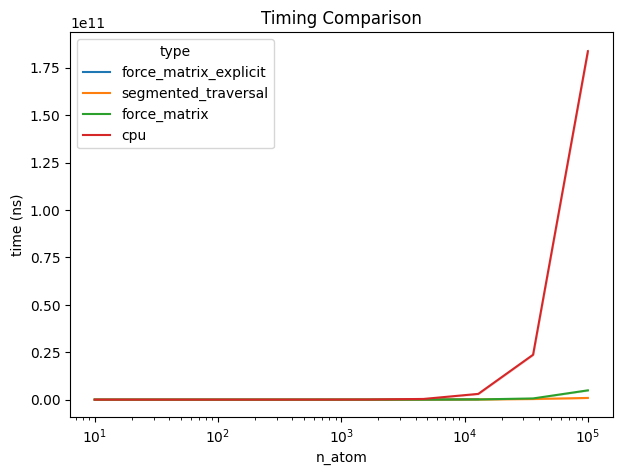

In [5]:
fig, ax = plt.subplots(figsize = (7, 5))
sns.lineplot(time_df, x = "n_atom", y = "time", hue = "type", ax = ax)
ax.set_xscale('log')
ax.set_ylabel("time (ns)")
ax.set_title("Timing Comparison")
fig.savefig("timing_comparison.png", dpi=300)

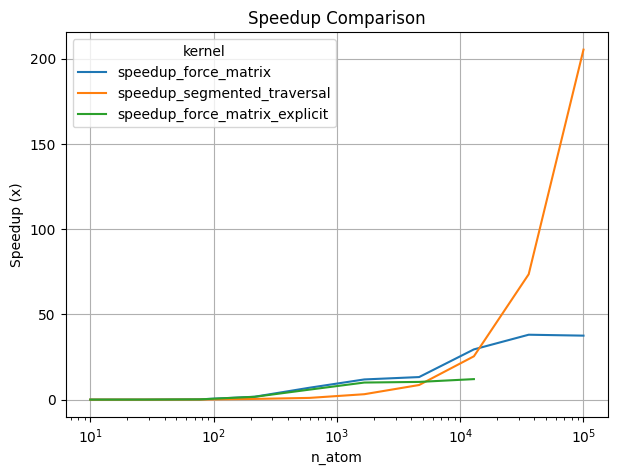

In [7]:
comp_df = time_df.groupby(by = ["n_atom", "type"])['time'].agg("mean").reset_index()
comp_df = comp_df.pivot(index = "n_atom", columns = "type", values = "time").reset_index()
comp_df['speedup_force_matrix'] = comp_df['cpu'] / comp_df['force_matrix']
comp_df['speedup_segmented_traversal'] = comp_df['cpu'] / comp_df['segmented_traversal']
comp_df['speedup_force_matrix_explicit'] = comp_df['cpu'] / comp_df['force_matrix_explicit']
comp_df = comp_df.melt(
  id_vars = 'n_atom',
  value_vars = ['speedup_force_matrix', 'speedup_segmented_traversal', 'speedup_force_matrix_explicit'],
  value_name = 'speedup',
  var_name = 'kernel'
)
fig, ax = plt.subplots(figsize = (7, 5))
sns.lineplot(comp_df, x='n_atom', y='speedup', hue='kernel', ax=ax)
ax.set_xscale('log')
ax.set_ylabel("Speedup (x)")
ax.grid()
ax.set_title("Speedup Comparison")
fig.savefig("speedup_comparison.png", dpi=300)

# Velocity Verlet Integration

1. Position update
$$ r(t+\Delta t) = r(t) + v(t)\Delta t + \frac{F(t)}{2m} \Delta t^2 $$
2. Velocity update
$$ v(t+\Delta t) = v(t) + \frac{F(t) + F(t+\Delta t)}{2m} \Delta t $$

Naive implementation
```{python}
for step in range(t_steps):
  forces = compute_forces(positions)  # F(t)
  v += 0.5 * forces / mass * dt
  positions += v * dt
  wrap(positions)
  forces = compute_forces(positions)  # F(t + dt)
  v += 0.5 * forces / mass * dt
  if step % rescale_interval == 0:
    v = rescale(v)
```

Notice that F(t + dt, step i-1) = F(t, step i)<br>
Pattern: (f 0.5v p f 0.5v rescale) (f 0.5v p f 0.5v) (f 0.5v p f 0.5v)<br>
Change to: (f 0.5v p) (f 0.5v rescale f 0.5v p) (f 0.5v f 0.5v p) (f 0.5v) <br>
Need to calculate: (f 0.5v p) (f 0.5v rescale 0.5v p) (f v p) <br>

Optimized sequential version
```{python}
# first iteration
// launch v_update
forces = compute_forces(positions)  # F(t)
v += 0.5 * forces / mass * dt
positions += v * dt
for step in range(1, t_steps):
  // launch v_update
  forces = compute_forces(positions)  # F(t + dt)
  dv = forces / mass * dt
  if (step-1) % rescale_interval == 0:
    v += 0.5 * dv
    v = rescale(v)
    v += 0.5 * dv
  else:
    v += dv
  positions += v * dt
  wrap(positions)
```

In [151]:
def rescale_d(velocities: cp.ndarray, mass: float, temperature: float):
  n = velocities.shape[1]
  ke = 1/2*cp.sum(mass * (cp.linalg.norm(velocities, axis=0)**2))
  cur_temp = 2/3 * ke / n
  velocities *= cp.sqrt(temperature / cur_temp)

def rescale_h(velocities: np.ndarray, mass: float, temperature: float):
  n = velocities.shape[1]
  ke = 1/2*np.sum(mass * (np.linalg.norm(velocities, axis=0)**2))
  cur_temp = 2/3 * ke / n
  velocities *= np.sqrt(temperature / cur_temp)

def write_traj(filename, frames):
  n = frames[0].shape[1]
  with open(filename, "w") as f:
    for pos in frames:
      f.write(f"{n}\nframe\n")
      for x, y, z in zip(pos[0], pos[1], pos[2]):
        if x<0 or y<0 or z<0:
          print(f"({x}, {y}, {z})")
        f.write(f"CG {x:.6f} {y:.6f} {z:.6f}\n")

In [160]:
# host function
def run_md(
  positions: cp.ndarray | np.ndarray, # 3 * n
  velocities: cp.ndarray | np.ndarray, # 3 * n
  compute_forces_func, # must have signature compute_forces_func(forces, positions)
  dt: float,
  mass: float,
  temperature: float,
  steps: int,
  box_size: float,
  rescale_interval: int,
  save_interval: int,
  device = False
):
  frames = np.zeros(shape = ((steps-1)//save_interval+1, 3, positions.shape[1]), dtype = np.float64)

  if device:
    forces = cp.zeros(shape = (3, positions.shape[1]), dtype = cp.float64)
  else:
    forces = np.zeros(shape = (3, positions.shape[1]), dtype = np.float64)

  compute_forces_func(forces, positions)
  velocities += 0.5 * forces / mass * dt
  positions += velocities * dt
  if device:
    positions -= box_size * cp.floor(positions / box_size)
  else:
    positions -= box_size * np.floor(positions / box_size)
  if device:
    frames[0] = positions.get()
  else:
    frames[0] = positions.copy()

  for step in tqdm(range(1, steps)):
    compute_forces_func(forces, positions)
    dv = forces / mass * dt

    if (step-1) % rescale_interval == 0:
      velocities += 0.5 * dv
      if device:
        rescale_d(velocities, mass, temperature)
      else:
        rescale_h(velocities, mass, temperature)
      velocities += 0.5 * dv
    else:
      velocities += dv

    positions += velocities * dt
    if device:
      positions -= box_size * cp.floor(positions / box_size)
    else:
      positions -= box_size * np.floor(positions / box_size)
    if step % save_interval == 0:
      if device:
        frames[step // save_interval] = positions.get()
      else:
        frames[step // save_interval] = positions.copy()
  
  return frames

In [161]:
def calc_force_matrix_wrapper(forces, positions):
  forces.fill(0)
  tile_n = math.ceil(positions.shape[1] / FORCE_MAT_TILE_DIM)
  grid_dim = tile_n * (1 + tile_n) // 2
  calc_force_matrix[grid_dim, FORCE_MAT_TILE_DIM](forces, positions, tile_n)

def calc_force_segmented_wrapper(forces, positions):
  grid_dim = (positions.shape[1] + SEGMENT - 1) // SEGMENT
  calc_force_segmented[grid_dim, SEGMENT](forces, positions)

In [154]:
n_atoms = 1000
k = 500
r0 = 1
box_size = n_atoms * r0 * 2.5
epsilon_attractive = 0.5
epsilon_repulsive = 1.0
sigma = 1.0
const_params = np.array([box_size, k, r0, epsilon_attractive, epsilon_repulsive, sigma])

seed = 42
rng_np = np.random.default_rng(seed)
rng_cp = cp.random.default_rng(seed)

dt = 0.01
mass = 1
temperature = 0.5
steps = 1001
rescale_interval = 100
save_interval = 10

pos = initialize_chain_numba(n_atoms, box_size, r0, rng_np, dtype = np.float64)
v = initialize_velocities_cupy(n_atoms, target_temperature=temperature, mass=mass, rng = rng_cp)

In [50]:
box_size

2500.0

In [162]:
positions_d = cp.array(pos)
velocities_d = v.copy()
forces_d = cp.zeros_like(pos)
frames_fm = run_md(
  positions_d, velocities_d, calc_force_matrix_wrapper, dt, mass, temperature,
  steps, box_size,
  rescale_interval,
  save_interval,
  device = True
)
write_traj(f"traj/force_matrix_n_{n_atoms}.xyz", frames_fm)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [163]:
positions_d = cp.array(pos)
velocities_d = v.copy()
frames_st = run_md(
  positions_d, velocities_d, calc_force_segmented_wrapper, dt, mass, temperature,
  steps, box_size,
  rescale_interval,
  save_interval,
  device = True
)
write_traj(f"traj/segment_n_{n_atoms}.xyz", frames_st)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [167]:
positions_h = pos.copy()
velocities_h = v.get()
forces_h = np.zeros_like(pos)
frames_cpu = run_md(
  positions_h, velocities_h, calc_force_sequential, dt, mass, temperature,
  steps, box_size,
  rescale_interval,
  save_interval,
  device = False
)
write_traj(f"traj/sequential_n_{n_atoms}.xyz", frames_cpu)

  0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2772: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real


In [168]:
def read_traj(traj):
  n_frames = 0
  with open(traj, 'r') as file:
    n_atoms = int(file.readline())
    for line in file:
      if line.strip().lower() == 'frame':
        n_frames += 1
      
  pos_line = re.compile(r'\w+\s+(\d+.\d+)\s+(\d+.\d+)\s+(\d+.\d+)')
  frames = np.zeros((n_frames, 3, n_atoms))
  with open(traj, 'r') as file:
    for frame in range(n_frames):
      file.readline() # reads atom number
      file.readline() # reads "frame"
      for atom_idx in range(n_atoms):
        line = file.readline().strip()
        pos = pos_line.search(line)
        for i in range(SPACE_N_DIM):
          x = float(pos.group(i+1))
          frames[frame, i, atom_idx] = x
  return frames

In [169]:
frames_st = read_traj("traj/segment_n_1000.xyz")
frames_cpu = read_traj("traj/sequential_n_1000.xyz")
frames_fm = read_traj("traj/force_matrix_n_1000.xyz")

In [170]:
np.allclose(frames_st, frames_fm)

True

In [172]:
np.all(frames_fm == frames_cpu, axis=-1)

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ T

In [177]:
np.allclose(frames_st[:50], frames_cpu[:50])

True